### Top
1. Imports & setup
2. Load WhatsApp message data
3. Load resident metadata
4. Engineer story dimensions
5. Aggregate to resident level
6. Dimension reduction
7. Visualization & interpretation


In [58]:
import seaborn as sns
import pandas as pd
# import pandasql as ps
from pathlib import Path
from loguru import logger
import numpy as np
import warnings
import matplotlib.pyplot as plt
import json
import tomllib
# import duckdb
import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


warnings.filterwarnings("ignore", category=FutureWarning)

### 2. Load WhatsApp message data

In [59]:
# Load data
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)
datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning(
        "Datafile does not exist. First run src/preprocess.py, and check the timestamp!"
    )
wa_df = pd.read_parquet(datafile)
wa_df.columns 


Index(['timestamp', 'message', 'author', 'has_emoji', 'is_topk',
       'message_length', 'has_link', 'timestamp_category', 'hour',
       'day_of_week', 'msg_length'],
      dtype='object')

In [60]:
# create an integer hour column
wa_df["hour_int"] = wa_df["timestamp"].dt.hour


In [61]:
wa_df[["hour", "hour_int"]].head()


,hour,hour_int
0,19:59:48,19
1,20:46:43,20
2,20:52:10,20
3,20:52:45,20
4,20:55:55,20


In [62]:
# Aggregate WhatsApp behavior to resident level
author_behavior_df = (
    wa_df
    .groupby("author")
    .agg(
        msg_count=("message", "count"),
        avg_msg_length=("msg_length", "mean"),
        emoji_rate=("has_emoji", "mean"),
        link_rate=("has_link", "mean"),
        night_msg_rate=("hour_int", lambda h: (h < 6).mean())
    )
    .reset_index()
)


### 3. Load resident metadata (dimensions source)

In [63]:
# --- Load metadata ---
with open("resident_metadata.json", "r") as f:
    nested_users = json.load(f)

author_dimensions_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={"index": "author"})
)

author_dimensions_df.head()



,author,Name,Gender,Entrance_nr,Unit_nr,Floor_nr,Nr_rooms,Board_function
0,bejeweled-beluga,JWF,Male,2,226,7,5,not_applicable
1,billowy-meerkat,CL,Male,2,242,7,5,not_applicable
2,bold-bison,C,Female,1,201,7,3,not_applicable
3,bouncy-worm,F,Female,2,238,5,5,not_applicable
4,cackling-eland,MS,Female,2,241,6,5,Algemeen bestuurslid 1


In [64]:
# Cleans a message by removing links, newlines, and excess whitespace.
        # text = str(text).lower()
        # text = re.sub(r"http\S+", "", text)  # remove links
        # text = text.replace("\n", " ")
        # text = re.sub(r"\s+", " ", text).strip()

### 4. Define your story dimensions

In [65]:
# Dimension 1: Entrance Location
# Interpretation:
# Which micro-community inside the building does this person belong to?
author_dimensions_df["entrance_location"] = author_dimensions_df["Entrance_nr"]


In [66]:
# Dimension 2: Vertical Position
# Interpretation:
# How dependent is this person on elevators and vertical infrastructure?
author_dimensions_df["vertical_position"] = author_dimensions_df["Floor_nr"]

### 6. Merge behavior + location story
This table is now your social map input.

In [67]:
resident_df = (
    author_behavior_df
    .merge(
        author_dimensions_df[
            [
                "author",
                "entrance_location",
                "vertical_position",
                "Nr_rooms",
                "Board_function"
            ]
        ],
        on="author",
        how="left"
    )
)

resident_df.head()


,author,msg_count,avg_msg_length,emoji_rate,link_rate,night_msg_rate,entrance_location,vertical_position,Nr_rooms,Board_function
0,bejeweled-beluga,4,243.750000,0.000000,0.000000,0.000000,2,7,5,not_applicable
1,billowy-meerkat,9,82.555556,0.000000,0.000000,0.000000,2,7,5,not_applicable
2,bold-bison,82,67.146341,0.317073,0.024390,0.000000,1,7,3,not_applicable
3,bouncy-worm,35,42.057143,0.028571,0.000000,0.057143,2,5,5,not_applicable
4,cackling-eland,106,126.698113,0.245283,0.028302,0.000000,2,6,5,Algemeen bestuurslid 1


### 7. Prepare data for dimension reduction
Select only numeric columns for PCA.

In [68]:
features = [
    "entrance_location",
    "vertical_position",
    "msg_count",
    "avg_msg_length",
    "emoji_rate",
    "link_rate",
]

X = resident_df[features].fillna(0)


In [69]:
# Standardize
X_scaled = StandardScaler().fit_transform(X)


### 8. Dimension reduction (PCA)
Interpretation:

dim_1 ≈ location + activity

dim_2 ≈ vertical dependency + communication style

(Exact meaning comes from loadings — optional deep dive later.)


In [70]:
# loadings = pd.DataFrame(
#     pca.components_.T,
#     index=features,
#     columns=["dim_1", "dim_2"]
# )

# loadings


In [71]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

resident_df["dim_1"] = X_pca[:, 0]
resident_df["dim_2"] = X_pca[:, 1]


In [72]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=["dim_1", "dim_2"]
)

loadings


,dim_1,dim_2
entrance_location,-0.171803,-0.224379
vertical_position,0.552402,0.280904
msg_count,0.098084,0.776327
avg_msg_length,0.242822,0.192163
emoji_rate,-0.509554,0.459293
link_rate,0.580609,-0.142080


### 9. Visualize the story

What this picture is:

This figure is a 2-dimensional projection of residents, where each point summarizes how a person participates in the WhatsApp group in relation to their physical position in the building.

Nothing more. Nothing less.

Step 1: What each dot represents

Each dot = one resident (author)

A dot is not a message, not a topic, not a personality

It is an aggregate behavioral profile, built from:

how much they post (msg_count)

how they post (avg_msg_length, emoji_rate, link_rate)

where they live (entrance_location, vertical_position)

So you compressed 6 dimensions → 2 dimensions.

That compression is what PCA does.


######

Step 2: What the axes mean (crucial)
X-axis: Social–Spatial Dimension 1

This axis mostly reflects a combination of:

activity level in the chat (posting frequency)

horizontal position in the building (entrance)

People far apart on this axis:

experience the building differently and

participate at different intensities

This is not agreement or disagreement — it’s participation context.



Y-axis: Social–Spatial Dimension 2

This axis mostly reflects:

vertical position (floor)

communication style (emoji use, message length)

High vs low on this axis suggests:

different daily routines

different modes of interaction with the group

Again: not personality — situated behavior.


Step 3: Why some people are far away
Example: intense-toad (top right)

That dot is far away because:

their combination of floor + entrance + activity + style

is unusual compared to the rest of the building

This does not mean:

they are extreme

they are dominant

they are socially different

It means:

Their behavioral + spatial profile explains a lot of variance.

PCA exaggerates difference to explain variance — that’s its job.

Step 4: Why most people are clustered

The dense cloud in the middle means:

Most residents:

live on comparable floors

post occasionally

use similar message lengths

have similar emoji/link habits

So PCA says:

“There is less variance here.”

That’s a finding, not a failure.

tep 5: What distance actually means (this is important)
Distance ≠ similarity of opinions
Distance ≠ social closeness
Distance ≠ linguistic identity

Distance means:

“If I had to describe these two residents using only the variables you gave me, I would need very different combinations.”

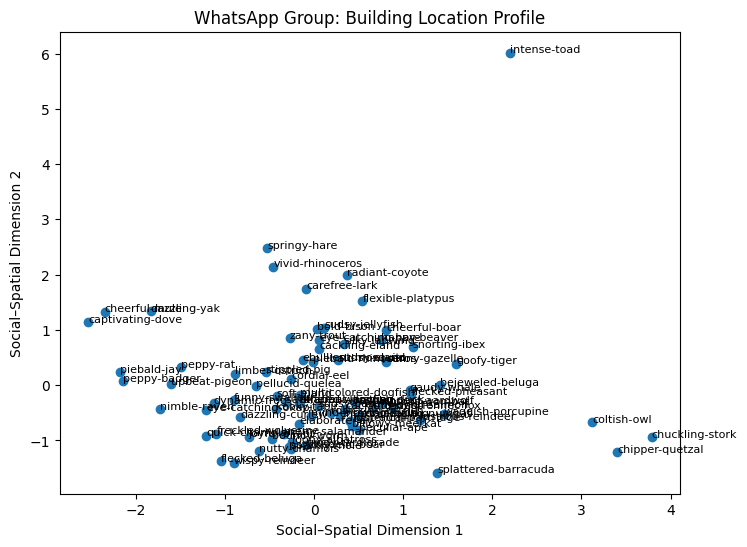

In [74]:
plt.figure(figsize=(8, 6))
plt.scatter(
    resident_df["dim_1"],
    resident_df["dim_2"],
)

for _, row in resident_df.iterrows():
    plt.text(row["dim_1"], row["dim_2"], row["author"], fontsize=8)

plt.xlabel("Social–Spatial Dimension 1")
plt.ylabel("Social–Spatial Dimension 2")
plt.title("WhatsApp Group: Building Location Profile")
plt.show()


### 10. How to explain this plot
ou can literally say:

“Each dot is one resident.
People close together experience the building — and use the WhatsApp group — in similar ways.
Distance means different daily realities, not disagreement.”